In [ ]:
from utils import load_data, split_data, preprocess, truncate_text
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

In [4]:
df, X, y = load_data()
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print("Liczba przykładów:")
print(f"  treningowych   {len(y_train):,}")
print(f"  walidacyjnych  {len(y_val):,}")
print(f"  testowych      {len(y_test):,}")

Liczba przykładów:
  treningowych   36,876
  walidacyjnych  7,902
  testowych      7,903


In [5]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("log_reg", LogisticRegression(max_iter=1_000))
])

In [6]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LinearSVC())
])

In [7]:
X_train_base = X_train.apply(preprocess)
X_val_base = X_val.apply(preprocess)
X_test_base = X_test.apply(preprocess)

### Eksperyment 3: wpływ długości tekstu na klasyfikację

In [27]:
X_train_100 = X_train_base.apply(lambda x: truncate_text(x, 100))
X_val_100 = X_val_base.apply(lambda x: truncate_text(x, 100))
X_test_100 = X_test_base.apply(lambda x: truncate_text(x, 100))

In [10]:
baseline.fit(X_train_100, y_train)
y_val_pred_100 = baseline.predict(X_val_100)
f1_macro_100 = f1_score(y_val, y_val_pred_100, average='macro')

print(classification_report(y_val, y_val_pred_100))
print(f"F1 macro: {f1_macro_100:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.77      0.59      0.67       576
             Bipolar       0.88      0.50      0.64       416
          Depression       0.56      0.68      0.61      2311
              Normal       0.78      0.89      0.83      2451
Personality disorder       0.97      0.24      0.39       162
              Stress       0.63      0.23      0.34       388
            Suicidal       0.58      0.52      0.55      1598

            accuracy                           0.67      7902
           macro avg       0.74      0.52      0.58      7902
        weighted avg       0.68      0.67      0.66      7902

F1 macro: 0.58


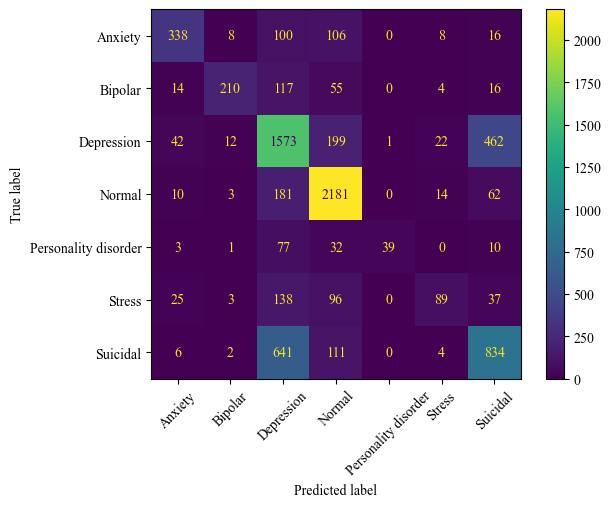

In [25]:
cm_100 = confusion_matrix(y_val, y_val_pred_100)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_100,
    xticks_rotation=45)

In [12]:
svm_pipeline.fit(X_train_100, y_train)
y_val_pred_svm_100 = svm_pipeline.predict(X_val_100)
f1_macro_svm_100 = f1_score(y_val, y_val_pred_svm_100, average='macro')

print(classification_report(y_val, y_val_pred_svm_100))
print(f"F1 macro: {f1_macro_svm_100:.2f}")

                      precision    recall  f1-score   support

             Anxiety       0.73      0.65      0.69       576
             Bipolar       0.79      0.57      0.66       416
          Depression       0.56      0.64      0.60      2311
              Normal       0.83      0.87      0.85      2451
Personality disorder       0.77      0.34      0.47       162
              Stress       0.55      0.32      0.40       388
            Suicidal       0.55      0.55      0.55      1598

            accuracy                           0.67      7902
           macro avg       0.68      0.56      0.60      7902
        weighted avg       0.67      0.67      0.66      7902

F1 macro: 0.60


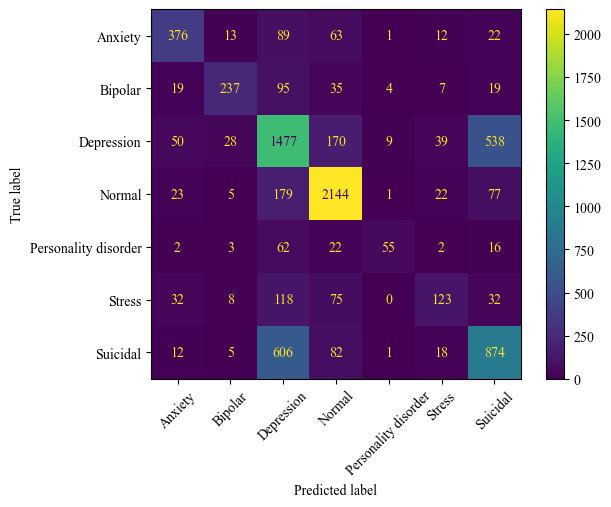

In [24]:
cm_100_svm = confusion_matrix(y_val, y_val_pred_svm_100)
ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred_svm_100,
    xticks_rotation=45)

In [14]:
def evaluate_length(X_train, X_val, y_train, y_val):
    lens = [50*n for n in range(1, 21)]
    f1_scores_lr = []
    f1_scores_svm = []

    for len in lens:
        X_train_trunc = X_train.apply(lambda x: truncate_text(x, len))
        X_val_trunc = X_val.apply(lambda x: truncate_text(x, len))

        baseline.fit(X_train_trunc, y_train)
        y_val_pred_lr_trunc = baseline.predict(X_val_trunc)
        f1_macro_lr_trunc = f1_score(y_val, y_val_pred_lr_trunc, average='macro')

        svm_pipeline.fit(X_train_trunc, y_train)
        y_val_pred_svm_trunc = svm_pipeline.predict(X_val_trunc)
        f1_macro_svm_trunc = f1_score(y_val, y_val_pred_svm_trunc, average='macro')

        f1_scores_lr.append(f1_macro_lr_trunc)
        f1_scores_svm.append(f1_macro_svm_trunc)
        print(f"Length={len}, LR F1 macro: {f1_macro_lr_trunc:.2f}, SVM F1 macro: {f1_macro_svm_trunc:.2f}")

    return lens, f1_scores_lr, f1_scores_svm

In [15]:
lens, f1_scores_lr, f1_scores_svm = evaluate_length(X_train_base, X_val_base, y_train, y_val)

Length=50, LR F1 macro: 0.50, SVM F1 macro: 0.53
Length=100, LR F1 macro: 0.58, SVM F1 macro: 0.60
Length=150, LR F1 macro: 0.60, SVM F1 macro: 0.65
Length=200, LR F1 macro: 0.62, SVM F1 macro: 0.66
Length=250, LR F1 macro: 0.65, SVM F1 macro: 0.67
Length=300, LR F1 macro: 0.65, SVM F1 macro: 0.68
Length=350, LR F1 macro: 0.66, SVM F1 macro: 0.69
Length=400, LR F1 macro: 0.66, SVM F1 macro: 0.70
Length=450, LR F1 macro: 0.67, SVM F1 macro: 0.70
Length=500, LR F1 macro: 0.67, SVM F1 macro: 0.70
Length=550, LR F1 macro: 0.68, SVM F1 macro: 0.70
Length=600, LR F1 macro: 0.68, SVM F1 macro: 0.70
Length=650, LR F1 macro: 0.68, SVM F1 macro: 0.71
Length=700, LR F1 macro: 0.68, SVM F1 macro: 0.71
Length=750, LR F1 macro: 0.68, SVM F1 macro: 0.71
Length=800, LR F1 macro: 0.68, SVM F1 macro: 0.71
Length=850, LR F1 macro: 0.68, SVM F1 macro: 0.72
Length=900, LR F1 macro: 0.68, SVM F1 macro: 0.72
Length=950, LR F1 macro: 0.69, SVM F1 macro: 0.72
Length=1000, LR F1 macro: 0.69, SVM F1 macro: 0.72


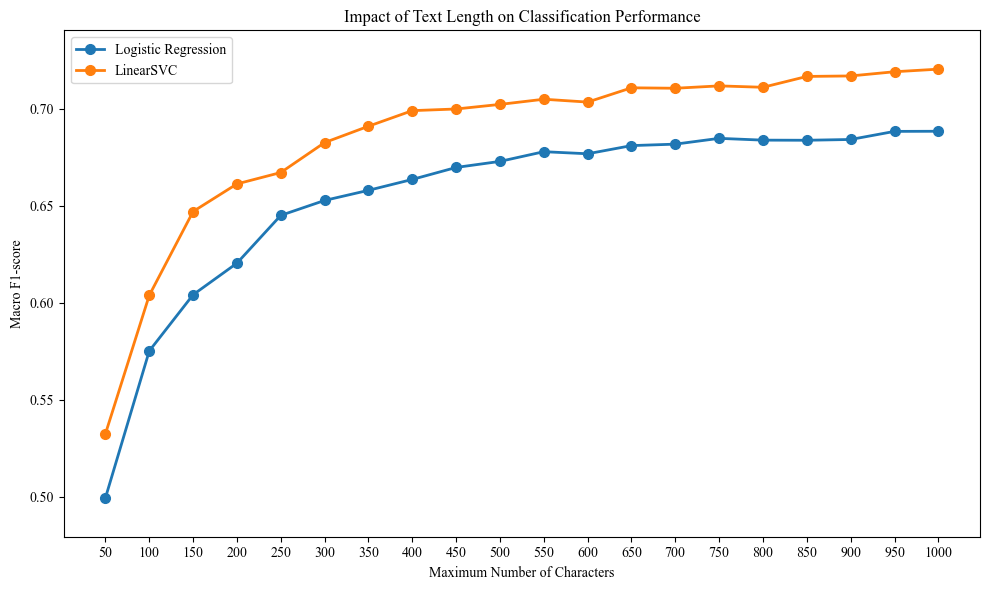

In [16]:
# wizualizacja wpływu długości tekstu na F1 macro
plt.figure(figsize=(10, 6))

plt.plot(
    lens,
    f1_scores_lr,
    marker='o',
    linewidth=2,
    markersize=7,
    label='Logistic Regression'
)

plt.plot(
    lens,
    f1_scores_svm,
    marker='o',
    linewidth=2,
    markersize=7,
    label='LinearSVC'
)

plt.title("Impact of Text Length on Classification Performance")
plt.xlabel("Maximum Number of Characters")
plt.ylabel("Macro F1-score")
plt.xticks(lens)

plt.legend()
plt.ylim(
    min(min(f1_scores_lr), min(f1_scores_svm)) - 0.02,
    max(max(f1_scores_lr), max(f1_scores_svm)) + 0.02
)

plt.tight_layout()
plt.show()

In [17]:
baseline.fit(X_train_base, y_train)
y_val_pred = baseline.predict(X_val_base)
report_base = classification_report(y_val, y_val_pred, output_dict=True)

svm_pipeline.fit(X_train_base, y_train)
y_val_pred_svm = svm_pipeline.predict(X_val_base)
report_svm_base = classification_report(y_val, y_val_pred_svm, output_dict=True)

report_100 = classification_report(y_val, y_val_pred_100, output_dict=True)
report_svm_100 = classification_report(y_val, y_val_pred_svm_100, output_dict=True)

In [18]:
classes = [
    c for c in report_base.keys()
    if c not in ['accuracy', 'macro avg', 'weighted avg']
]

comparison = pd.DataFrame({
    "full_text": [
        report_base[c]["f1-score"]
        for c in classes
    ],
    "truncated": [
        report_100[c]["f1-score"]
        for c in classes
    ],
    "full_text (SVM)": [
        report_svm_base[c]["f1-score"]
        for c in classes
    ],
    "truncated (SVM)": [
        report_svm_100[c]["f1-score"]
        for c in classes
    ]
}, index=classes)

comparison["drop"] = (
    comparison["full_text"]
    - comparison["truncated"]
)
comparison["drop (svm)"] = (
    comparison["full_text (SVM)"]
    - comparison["truncated (SVM)"]
)
comparison = comparison.sort_values(
    "drop",
    ascending=False
)

comparison

,full_text,truncated,full_text (SVM),truncated (SVM),drop,drop (svm)
Personality disorder,0.607287,0.386139,0.695341,0.472103,0.221149,0.223237
Stress,0.518405,0.336484,0.570597,0.402619,0.181921,0.167978
Suicidal,0.684110,0.549588,0.671237,0.550378,0.134522,0.120859
Depression,0.718394,0.612301,0.714225,0.598339,0.106094,0.115885
Anxiety,0.755389,0.666667,0.793988,0.689908,0.088722,0.104079
Bipolar,0.724187,0.641221,0.753927,0.662937,0.082965,0.090990
Normal,0.898916,0.833875,0.911567,0.850456,0.065041,0.061111


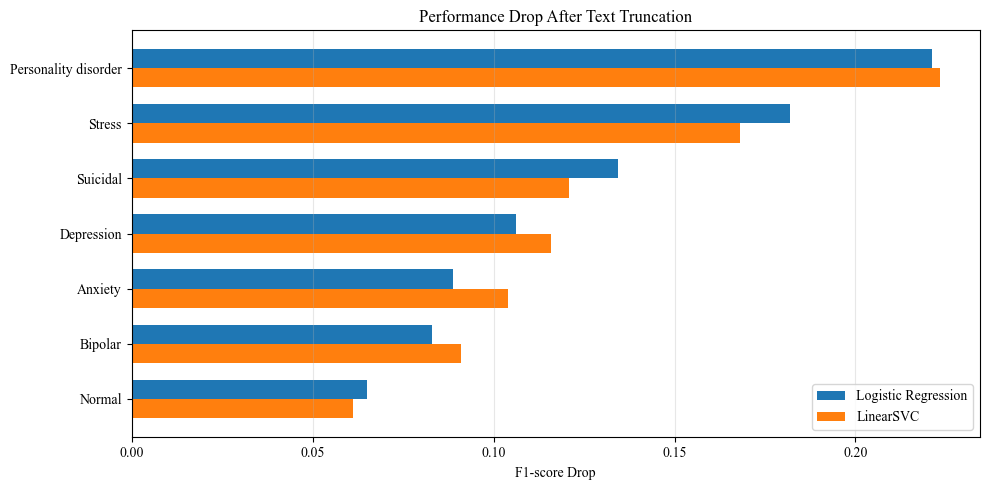

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(comparison.index))
bar_height = 0.35

ax.barh(
    y - bar_height/2,
    comparison["drop"],
    height=bar_height,
    label="Logistic Regression"
)
ax.barh(
    y + bar_height/2,
    comparison["drop (svm)"],
    height=bar_height,
    label="LinearSVC"
)

ax.set_yticks(y)
ax.set_yticklabels(comparison.index)
ax.set_xlabel("F1-score Drop")
ax.set_title(
    "Performance Drop After Text Truncation"
)
ax.invert_yaxis()
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
df["length"] = df["statement"].str.len()

avg_lengths = (
    df.groupby("status")["length"]
    .mean()
)

comparison["avg_length"] = (
    comparison.index
    .map(avg_lengths)
)

In [23]:
corr_lr = comparison["avg_length"].corr(
    comparison["drop"]
)
corr_svm = comparison["avg_length"].corr(
    comparison["drop (svm)"]
)
print("Correlation (LR):", round(corr_lr, 3))
print("Correlation (SVM):", round(corr_svm, 3))

Correlation (LR): 0.404
Correlation (SVM): 0.514
